# Dataframe catchments

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sbn

import warnings
warnings.filterwarnings('ignore')

In [2]:
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchments_OK.gpkg")
cluster.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787...."


In [3]:
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/subbasins_Ks_zonalStatistic.gpkg")
cat.tail(1)

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,_Kscount,_Ksmean,_Ksmedian,_Ksstdev,_Ksmin,_Ksmax,_Ksrange,geometry
651,664,651.0,1.0,328.97443,Quebrada La Paja,651,0.336,0.32287,D,4609.0,33.448628,23.666,32.850318,0.006619,196.75,196.743381,"MULTIPOLYGON (((423759.438 739547.404, 423787...."


In [4]:
cat_1 = cluster.merge(cat[["ID_CUENCA","hypso_inte","_Ksmean"]], on='ID_CUENCA')
cat_1.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628


In [5]:
chi_cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/subbasins_chi_zonalStatistic.gpkg")
chi_cat.head(1)

,OBJECTID,Id,gridcode,Área,Nombre,ID_CUENCA,hypso_inte,area_curva,Knickpoint,_chicount,_chimean,_chimedian,_chistdev,_chimin,_chimax,geometry
0,1,0.0,2827.0,120.181924,Quebrada Los San Andreses,0,0.107,0.096501,A,1362.0,10.017347,10.076,2.848651,4.6349,16.011,"MULTIPOLYGON (((411860.438 900002.542, 411964...."


In [6]:
cat_2 = cat_1.merge(chi_cat[["ID_CUENCA","_chimean"]], on='ID_CUENCA')
cat_2.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495


In [7]:
cat_lin=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/hypso3.gpkg")
cat_lin.reset_index(inplace=True)
cat_lin.rename(columns={"index":"ID_CUENCA"}, inplace=True)
cat_lin.head(1)

,ID_CUENCA,OBJECTID,Id,gridcode,Área,hypso_inte,area_curva,Shape_Leng,Shape_Le_1,Shape_Area,Nombre,Lineamient,Densidad,_mean,knickpoint,geometry
0,0,1,4.0,2827.0,120.181924,0.107,0.096448,59628.024115,59459.370531,1.201791e+08,Quebrada Los San Andreses,294.0,2.446291,2250.332866,E,"MULTIPOLYGON (((411860.438 900002.542, 411964...."


In [8]:
cat_3 = cat_2.merge(cat_lin[["ID_CUENCA","_mean","Densidad"]], on='ID_CUENCA')
cat_3.rename(columns={"_mean":"rainfall_cat"}, inplace=True)
cat_3.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988


In [9]:
cat_elev=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/elev_zonal_statistic.gpkg")
cat_elev.tail(1)

,Área,Nombre,ID_CUENCA,elev_mean,elev_median,elev_min,elev_max,elev_range,geometry
651,328.97443,Quebrada La Paja,651,2634.928196,2594.0,2294.591553,3309.0,1014.408447,"MULTIPOLYGON (((423759.438 739547.404, 423787...."


In [10]:
cat_4 = cat_3.merge(cat_elev[["ID_CUENCA","elev_mean"]], on='ID_CUENCA')
cat_4.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,2634.928196


In [11]:
cat_slope=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/slope_zonal_statistic.gpkg")
cat_slope.tail(1)

,Nombre,ID_CUENCA,slope_mean,slope_median,slope_min,slope_max,slope_range,geometry
651,Quebrada La Paja,651,14.381317,13.592371,0.0,72.365318,72.365318,"MULTIPOLYGON (((423759.438 739547.404, 423787...."


In [12]:
cat_5 = cat_4.merge(cat_slope[["ID_CUENCA","slope_mean"]], on='ID_CUENCA')
cat_5.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean,slope_mean
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,2634.928196,14.381317


In [13]:
cat_relief=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchments_relief.shp")
cat_relief.tail(1)

,fid,ID_CUENCA,Nombre,kmeans,tskmeans_d,tskmeans_s,knn_1,knn_2,knn_4,knn_10,hc,rel_count,rel_mean,rel_median,rel_stdev,rel_min,rel_max,rel_range,geometry
651,652.0,651.0,Quebrada La Paja,B,D,B,B,D,D,D,A,370598.0,197.551795,170.0,123.466447,0.0,969.0,969.0,"POLYGON ((423759.438 739547.404, 423787.738 73..."


In [14]:
cat_6 = cat_5.merge(cat_relief[["ID_CUENCA","rel_mean","kmeans"]], on='ID_CUENCA')
cat_6.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean,slope_mean,rel_mean,kmeans
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,2634.928196,14.381317,197.551795,B


In [15]:
cat_rain=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/RainfallDays.gpkg")
cat_7 = cat_6.merge(cat_rain[["ID_CUENCA",'RainfallDaysmean','RainfallDaysmedian','RainfallDaysstdev','RainfallDaysmin','RainfallDaysmax']], on='ID_CUENCA')
cat_7.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean,slope_mean,rel_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,RainfallDaysstdev,RainfallDaysmin,RainfallDaysmax
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,2634.928196,14.381317,197.551795,B,417.0,391.0,96.975083,267.0,618.0


### Recent landslides

In [16]:
recent=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2.gpkg")
rec=recent[["geometry","Name"]].to_crs(epsg=32618)
rec.tail(1)

,geometry,Name
13776,POINT Z (456910.258 734239.312 0.000),01/2024


In [17]:
rec_cat = gpd.sjoin(rec, cluster, how="inner")
rec_cat.tail(1)

,geometry,Name,index_right,Nombre,ID_CUENCA,cuenca,area
13765,POINT Z (459003.157 721671.364 0.000),06/2018,72,Quebrada Mocorongo,561.0,Cauca,17874362


In [18]:
rec_by_cat=rec_cat.groupby("ID_CUENCA").size()
rec_cat_df=pd.DataFrame({"lands_rec": rec_by_cat})
rec_cat_df.tail(2)

,lands_rec
ID_CUENCA,
650.0,2
651.0,46


In [19]:
cat_8 = cat_7.join(rec_cat_df,on="ID_CUENCA")
cat_8["lands_rec"]=cat_8["lands_rec"].fillna(0)
cat_8.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,elev_mean,slope_mean,rel_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,RainfallDaysstdev,RainfallDaysmin,RainfallDaysmax,lands_rec
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,2634.928196,14.381317,197.551795,B,417.0,391.0,96.975083,267.0,618.0,46.0


### Relict landslides

In [20]:
relict=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_rainfall.gpkg")
rel=relict[["geometry","Name"]].to_crs(epsg=32618)
rel.tail(1)

,geometry,Name
221,POINT Z (452907.806 809909.132 747.913),K206


In [21]:
rel_cat = gpd.sjoin(rel, cluster, how="inner")
rel_cat.tail(1)

,geometry,Name,index_right,Nombre,ID_CUENCA,cuenca,area
221,POINT Z (452907.806 809909.132 747.913),K206,492,Quebrada La Siberia,417.0,Cauca,118436251


In [22]:
rel_by_cat=rel_cat.groupby("ID_CUENCA").size()
rel_cat_df=pd.DataFrame({"lands_rel": rel_by_cat})
rel_cat_df.tail(1)

,lands_rel
ID_CUENCA,
651.0,1


In [23]:
cat_9 = cat_8.join(rel_cat_df,on="ID_CUENCA")
cat_9["lands_rel"]=cat_9["lands_rel"].fillna(0)
cat_9.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,...,slope_mean,rel_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,RainfallDaysstdev,RainfallDaysmin,RainfallDaysmax,lands_rec,lands_rel
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,...,14.381317,197.551795,B,417.0,391.0,96.975083,267.0,618.0,46.0,1.0


In [24]:
cat_9["landslides"]=cat_9["lands_rec"]+cat_9["lands_rel"]
cat_9.tail(1)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,...,rel_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,RainfallDaysstdev,RainfallDaysmin,RainfallDaysmax,lands_rec,lands_rel,landslides
642,Quebrada La Paja,651.0,Cauca,329202581,"MULTIPOLYGON (((423759.438 739547.404, 423787....",0.336,33.448628,22.987495,1618.777632,6.957988,...,197.551795,B,417.0,391.0,96.975083,267.0,618.0,46.0,1.0,47.0


#### knickpoints

In [25]:
kick5=gpd.read_file("G:\My Drive\INVESTIGACION\POSDOC\Data\Vector\Knickpoints_100m_5km2/Knicpoints_100m_5000.shp")
kick5.head(1)

,id,distan,z,IXgrid,order,dz,geometry
0,1,270501.175807,2278,57808273,1,942.43607,POINT (426946.165 712026.677)


In [26]:
kick5.drop(["id","IXgrid"],axis=1,inplace=True)

In [27]:
knick_cat = gpd.sjoin(kick5, cluster, how="inner")
knick_cat.tail(1)

,distan,z,order,dz,geometry,index_right,Nombre,ID_CUENCA,cuenca,area
733,432651.707328,1598,162,101.324152,POINT (450136.677 604206.976),384,Quebrada Platanillal(Quebrada El Dividente),300.0,Cauca,100031736


In [28]:
knick_by_cat=knick_cat.groupby("ID_CUENCA").size()
knick_cat_df=pd.DataFrame({"knick": knick_by_cat})
knick_cat_df.tail(1)

,knick
ID_CUENCA,
651.0,1


In [29]:
cat_10 = cat_9.join(knick_cat_df,on="ID_CUENCA")
cat_10["knick"]=cat_10["knick"].fillna(0)

In [31]:
cat_10.head(2)

,Nombre,ID_CUENCA,cuenca,area,geometry,hypso_inte,_Ksmean,_chimean,rainfall_cat,Densidad,...,kmeans,RainfallDaysmean,RainfallDaysmedian,RainfallDaysstdev,RainfallDaysmin,RainfallDaysmax,lands_rec,lands_rel,landslides,knick
0,Quebrada La Cristalina,501.0,Sinu,109086455,"MULTIPOLYGON (((344147.840 850184.150, 344333....",0.515,48.364910,14.743631,4236.130673,12.341726,...,D,3284.000000,3300.5,222.217236,2960.0,3575.0,0.0,0.0,0.0,0.0
1,Quebrada NN036,490.0,Sinu,70676516,"MULTIPOLYGON (((352368.983 860745.293, 352400....",0.426,42.219795,11.445477,3650.406254,15.143207,...,B,2559.031878,2570.0,386.729911,1938.0,3240.0,0.0,0.0,0.0,0.0


### Export

In [48]:
cat_10.to_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/df2_catchments.gpkg", driver="GPKG")

In [49]:
cat_10.to_csv(r"G:/My Drive/INVESTIGACION/POSDOC/GLM/df2.csv", index=False)

## Por deslizamientos

In [32]:
cat_rel=cat_10[cat_10["lands_rel"]>0]
cat_rec=cat_10[cat_10["lands_rec"]>0]
cat_land=cat_10[cat_10["landslides"]>0]
cat_nland=cat_10[cat_10["landslides"]==0]

In [40]:
cat_rel["landslides"].count()

78

In [41]:
cat_nland["landslides"].count()

246

In [42]:
cat_rel["landslides"].count()/(cat_nland["landslides"].count()+cat_land["landslides"].count())

0.1196319018404908

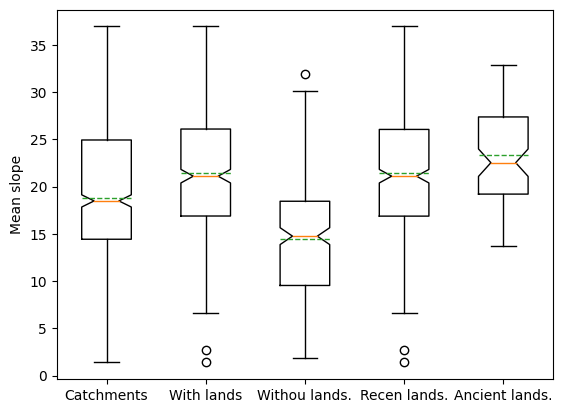

In [128]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["slope_mean"],cat_land["slope_mean"],cat_nland["slope_mean"],cat_rec["slope_mean"],cat_rel["slope_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean slope')
plt.xticks([1,2,3,4,5],['Catchments','With lands','Withou lands.','Recen lands.','Ancient lands.']);

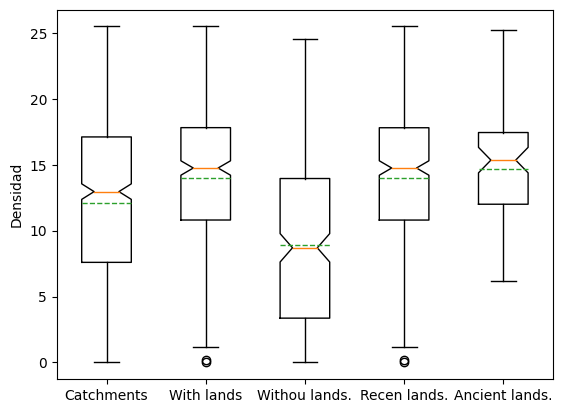

In [33]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["Densidad"],cat_land["Densidad"],cat_nland["Densidad"],cat_rec["Densidad"],cat_rel["Densidad"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Densidad')
plt.xticks([1,2,3,4,5],['Catchments','With lands','Withou lands.','Recen lands.','Ancient lands.']);

In [134]:
cat_land["slope_mean"].std()

5.887884977652802

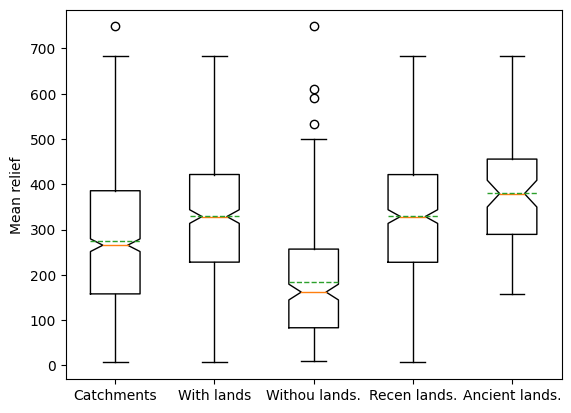

In [130]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["rel_mean"],cat_land["rel_mean"],cat_nland["rel_mean"],cat_rec["rel_mean"],cat_rel["rel_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean relief')
plt.xticks([1,2,3,4,5],['Catchments','With lands','Withou lands.','Recen lands.','Ancient lands.']);

In [138]:
cat_nland["rel_mean"].mean()

185.25097972063193

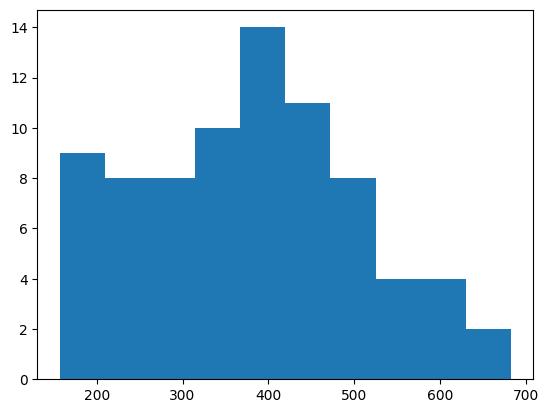

In [39]:
plt.hist(cat_rel["rel_mean"]);

(array([13., 37., 48., 53., 63., 61., 46., 24., 15.,  4.]),
 array([ 52.21062035, 115.24643784, 178.28225533, 241.31807282,
        304.35389031, 367.3897078 , 430.42552529, 493.46134278,
        556.49716027, 619.53297776, 682.56879525]),
 <BarContainer object of 10 artists>)

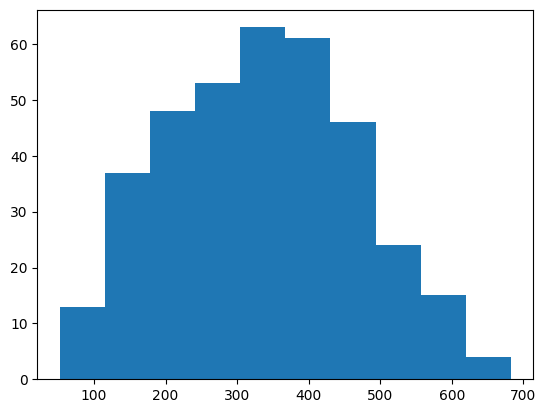

In [40]:
plt.hist(cat_rec["rel_mean"]);

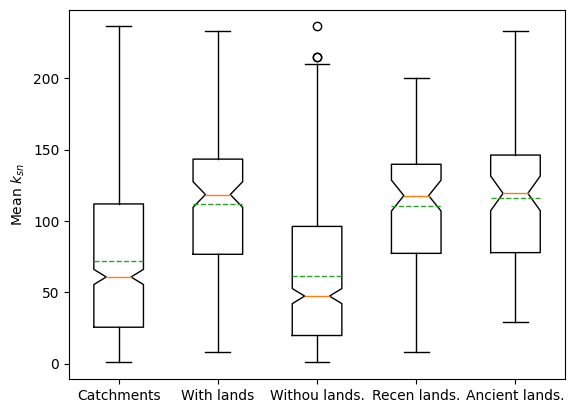

In [36]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["_Ksmean"],cat_land["_Ksmean"],cat_nland["_Ksmean"],cat_rec["_Ksmean"],cat_rel["_Ksmean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean $k_{sn}$')
plt.xticks([1,2,3,4,5],['Catchments','With lands','Withou lands.','Recen lands.','Ancient lands.']);

In [ ]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["_chimean"],cat_land["_chimean"],cat_nland["_chimean"],cat_rec["_chimean"],cat_rel["_chimean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean $\chi$')
plt.xticks([1,2,3,4,5],['Catchments','With lands','Withou lands.','Recen lands.','Ancient lands.']);

## Por cluster

In [78]:
catA=cat_10[cat_10["kmeans"]=="A"]
catB=cat_10[cat_10["kmeans"]=="B"]
catC=cat_10[cat_10["kmeans"]=="C"]
catD=cat_10[cat_10["kmeans"]=="D"]

In [81]:
catA.columns

Index(['Nombre', 'ID_CUENCA', 'cuenca', 'area', 'geometry', 'hypso_inte',
       '_Ksmean', '_chimean', 'rainfall_cat', 'Densidad', 'elev_mean',
       'slope_mean', 'rel_mean', 'kmeans', 'RainfallDaysmean',
       'RainfallDaysmedian', 'RainfallDaysstdev', 'RainfallDaysmin',
       'RainfallDaysmax', 'lands_rec', 'lands_rel', 'landslides', 'knick'],
      dtype='object')

In [82]:
catA["landslides"].sum()/catA["area"].sum()

4.92363540056933e-08

In [83]:
catB["landslides"].sum()/catB["area"].sum()

3.1151479876647096e-07

In [84]:
catC["landslides"].sum()/catC["area"].sum()

3.3080016852500065e-07

In [85]:
catD["landslides"].sum()/catD["area"].sum()

2.1794717066919517e-07

In [ ]:
print(catA["knick"].sum()/cat_11["knick"].sum())
print(catB["knick"].sum()/cat_11["knick"].sum())
print(catC["knick"].sum()/cat_11["knick"].sum())
print(catD["knick"].sum()/cat_11["knick"].sum())

In [190]:
catB[catB["knick"]>0].count()/catB.count()

ID_CUENCA             0.290909
Nombre                0.290909
kmeans                0.290909
geometry              0.290909
Área                  0.290909
hypso_inte            0.290909
_Ksmean               0.290909
_chimean              0.290909
rainfall_cat          0.290909
Densidad              0.290909
elev_mean             0.290909
slope_mean            0.290909
rel_mean              0.290909
cuenca                0.290909
RainfallDaysmean      0.290909
RainfallDaysmedian    0.290909
RainfallDaysstdev     0.290909
RainfallDaysmin       0.290909
RainfallDaysmax       0.290909
lands_rec             0.290909
lands_rel             0.290909
landslides            0.290909
knick                 0.290909
dtype: float64

#### Porcentage de cuencas con deslizamientos

In [141]:
landA.Nombre.count()/catA.Nombre.count()

0.325

In [142]:
landB.Nombre.count()/catB.Nombre.count()

0.5757575757575758

In [143]:
landC.Nombre.count()/catC.Nombre.count()

0.79375

In [144]:
landD.Nombre.count()/catD.Nombre.count()

0.6456692913385826

#### Porcentage de cuencas con deslizamientos recientes

In [145]:
recA.Nombre.count()/catA.Nombre.count()

0.325

In [146]:
recB.Nombre.count()/catB.Nombre.count()

0.5696969696969697

In [147]:
recC.Nombre.count()/catC.Nombre.count()

0.78125

In [148]:
recD.Nombre.count()/catD.Nombre.count()

0.6299212598425197

#### Porcentage de cuencas con deslizamientos ancient

In [149]:
relA.Nombre.count()/catA.Nombre.count()

0.04

In [150]:
relB.Nombre.count()/catB.Nombre.count()

0.08484848484848485

In [151]:
relC.Nombre.count()/catC.Nombre.count()

0.225

In [152]:
relD.Nombre.count()/catD.Nombre.count()

0.15748031496062992

In [36]:
landA=cat_10[(cat_10["kmeans"]=="A")&(cat_9["landslides"]>0)]
landB=cat_10[(cat_10["kmeans"]=="B")&(cat_9["landslides"]>0)]
landC=cat_10[(cat_10["kmeans"]=="C")&(cat_9["landslides"]>0)]
landD=cat_10[(cat_10["kmeans"]=="D")&(cat_9["landslides"]>0)]

In [37]:
recA=cat_10[(cat_10["kmeans"]=="A")&(cat_9["lands_rec"]>0)]
recB=cat_10[(cat_10["kmeans"]=="B")&(cat_9["lands_rec"]>0)]
recC=cat_10[(cat_10["kmeans"]=="C")&(cat_9["lands_rec"]>0)]
recD=cat_10[(cat_10["kmeans"]=="D")&(cat_9["lands_rec"]>0)]

In [38]:
relA=cat_10[(cat_10["kmeans"]=="A")&(cat_9["lands_rel"]>0)]
relB=cat_10[(cat_10["kmeans"]=="B")&(cat_9["lands_rel"]>0)]
relC=cat_10[(cat_10["kmeans"]=="C")&(cat_9["lands_rel"]>0)]
relD=cat_10[(cat_10["kmeans"]=="D")&(cat_9["lands_rel"]>0)]

In [156]:
print(landA['landslides'].sum())
print(landB['landslides'].sum())
print(landC['landslides'].sum())
print(landD['landslides'].sum())

816.0
4065.0
4405.0
2092.0


In [163]:
(landB['landslides'].sum()+landC['landslides'].sum())/cat_10['landslides'].sum()

0.7444190543153454

In [158]:
print(relA['lands_rel'].sum())
print(relB['lands_rel'].sum())
print(relC['lands_rel'].sum())
print(relD['lands_rel'].sum())

12.0
26.0
86.0
37.0


In [46]:
relA['lands_rel'].sum()/cat_10['lands_rel'].sum()

0.07453416149068323

In [168]:
(55+3317+54+1081)/(13777+222)

0.32195156796914065

In [39]:
print(recA['lands_rec'].sum())
print(recB['lands_rec'].sum())
print(recC['lands_rec'].sum())
print(recD['lands_rec'].sum())

804.0
4039.0
4319.0
2054.0


In [47]:
recA['lands_rec'].sum()/cat_10['lands_rec'].sum()

0.0716833095577746

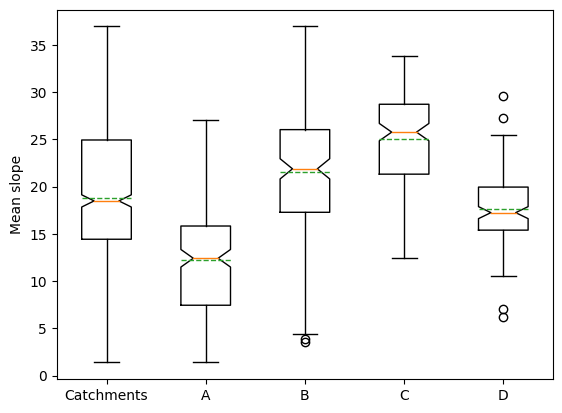

In [162]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["slope_mean"],catA["slope_mean"],catB["slope_mean"],catC["slope_mean"],catD["slope_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean slope')
plt.xticks([1,2,3,4,5],['Catchments','A','B','C','D']);

In [ ]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["rel_mean"],catA["rel_mean"],catB["rel_mean"],catC["rel_mean"],catD["rel_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean relief')
plt.xticks([1,2,3,4,5],['Catchments','A','B','C','D']);

In [ ]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["hypso_inte"],catA["hypso_inte"],catB["hypso_inte"],catC["hypso_inte"],catD["hypso_inte"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Hypsometric index')
plt.xticks([1,2,3,4,5],['Catchments','A','B','C','D']);

In [ ]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["_Ksmean"],catA["_Ksmean"],catB["_Ksmean"],catC["_Ksmean"],catD["_Ksmean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean $k{sn}$')
plt.xticks([1,2,3,4,5],['Catchments','A','B','C','D']);

In [ ]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["_chimean"],catA["_chimean"],catB["_chimean"],catC["_chimean"],catD["_chimean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean $\chi$')
plt.xticks([1,2,3,4,5],['Catchments','A','B','C','D']);

## Por Basin

In [86]:
cat_10.groupby("cuenca").size()

cuenca
Atrato       132
Cauca        324
Magdalena    130
San Juan      22
Sinu          35
dtype: int64

In [33]:
cat_10.columns

Index(['Nombre', 'ID_CUENCA', 'cuenca', 'area', 'geometry', 'hypso_inte',
       '_Ksmean', '_chimean', 'rainfall_cat', 'Densidad', 'elev_mean',
       'slope_mean', 'rel_mean', 'kmeans', 'RainfallDaysmean',
       'RainfallDaysmedian', 'RainfallDaysstdev', 'RainfallDaysmin',
       'RainfallDaysmax', 'lands_rec', 'lands_rel', 'landslides', 'knick'],
      dtype='object')

In [34]:
cat_10["area"].sum()

52532523694

#### Knickpoints

In [110]:
recent_elev=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_elev.gpkg")
recent_chi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent2_chi.gpkg")

In [111]:
rec_elev=gpd.sjoin(recent_elev, cat_cuencas, how="inner")
rec_chi=gpd.sjoin(recent_chi, cat_cuencas, how="inner")

In [112]:
print(rec_elev.columns)
print(rec_chi.columns)

Index(['Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'date',
       'source', 'elevation1', 'geometry', 'index_right', 'Nombre',
       'ID_CUENCA', 'cuenca'],
      dtype='object')
Index(['Name', 'description', 'timestamp', 'begin', 'end', 'altitudeMode',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'date',
       'source', 'elevation1', 'rainfall1', 'latitude', 'longitude', 'chi',
       'elevation', 'flow_dista', 'source_key', 'basin_key', 'n', 'distance',
       'feature_x', 'feature_y', 'nearest_x', 'nearest_y', 'geometry',
       'index_right', 'Nombre', 'ID_CUENCA', 'cuenca'],
      dtype='object')


In [121]:
rec_elev_cauca=rec_elev[(rec_elev["cuenca"]=="Cauca")]
rec_elev_magda=rec_elev[(rec_elev["cuenca"]=="Magdalena")]
rec_elev_atrato=rec_elev[(rec_elev["cuenca"]=="Atrato")]

In [122]:
rec_chi_cauca=rec_chi[(rec_chi["cuenca"]=="Cauca")]
rec_chi_magda=rec_chi[(rec_chi["cuenca"]=="Magdalena")]
rec_chi_atrato=rec_chi[(rec_chi["cuenca"]=="Atrato")]

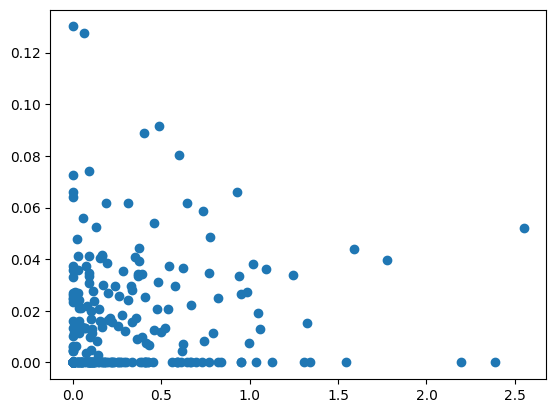

In [161]:

plt.scatter(cat_cauca.lands_rec/cat_cauca.Área,cat_cauca.knick/cat_cauca.Área)

In [87]:
cat_cauca=cat_10[(cat_10["cuenca"]=="Cauca")]
cat_magda=cat_10[(cat_10["cuenca"]=="Magdalena")]
cat_atrato=cat_10[(cat_10["cuenca"]=="Atrato")]

In [39]:
cat_cauca["lands_rec"].sum()

6665.0

In [88]:
cat_cauca["landslides"].sum()/cat_cauca["area"].sum()

2.514287625072282e-07

In [49]:
cat_cauca["knick"].sum()/cat_cauca["area"].sum()

1.2827241496240188e-08

In [89]:
cat_magda["landslides"].sum()/cat_magda["area"].sum()

1.8475685815276306e-07

In [40]:
cat_magda["lands_rec"].sum()

1862.0

In [50]:
cat_magda["knick"].sum()/cat_magda["area"].sum()

1.3225116983157185e-08

In [41]:
cat_atrato["lands_rec"].sum()

2379.0

In [90]:
cat_atrato["landslides"].sum()/cat_atrato["area"].sum()

2.2034318922592314e-07

In [51]:
cat_atrato["knick"].sum()/cat_atrato["area"].sum()

6.951466326762208e-09

In [90]:
cat_cauca["knick"].sum()+cat_magda["knick"].sum()+cat_atrato["knick"].sum()

558.0

In [88]:
cat_cauca["knick"].sum()/(cat_cauca["knick"].sum()+cat_magda["knick"].sum()+cat_atrato["knick"].sum())

0.6218637992831542

In [89]:
cat_magda["knick"].sum()/(cat_cauca["knick"].sum()+cat_magda["knick"].sum()+cat_atrato["knick"].sum())

0.24193548387096775

In [96]:
knick_cat.head(1)

,distan,z,order,dz,geometry,index_right,Nombre,ID_CUENCA,cuenca
0,270501.175807,2278,1,942.43607,POINT (426946.165 712026.677),440,Río Aurra,357,Cauca


In [97]:
knick_cauca=knick_cat[(knick_cat["cuenca"]=="Cauca")]
knick_magda=knick_cat[(knick_cat["cuenca"]=="Magdalena")]
knick_atrato=knick_cat[(knick_cat["cuenca"]=="Atrato")]

In [102]:
print(knick_cauca.z.mean())
print(knick_magda.z.mean())
print(knick_atrato.z.mean())

1529.5763688760808
1398.5407407407408
1631.3815789473683


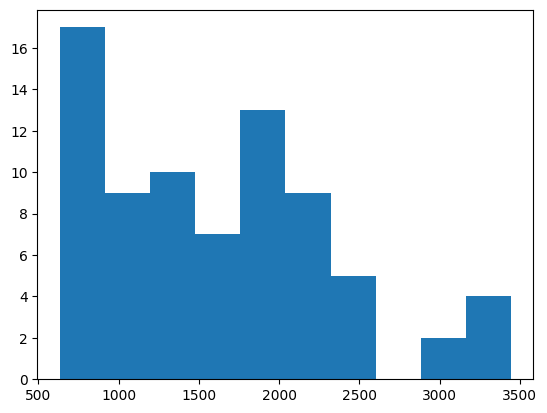

In [107]:
plt.hist(knick_atrato["z"]);

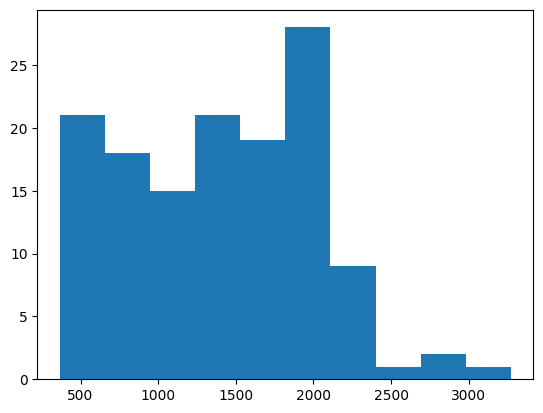

In [109]:
plt.hist(knick_magda["z"]);

In [91]:
cat_cauca.columns

Index(['Nombre', 'ID_CUENCA', 'cuenca', 'area', 'geometry', 'hypso_inte',
       '_Ksmean', '_chimean', 'rainfall_cat', 'Densidad', 'elev_mean',
       'slope_mean', 'rel_mean', 'kmeans', 'RainfallDaysmean',
       'RainfallDaysmedian', 'RainfallDaysstdev', 'RainfallDaysmin',
       'RainfallDaysmax', 'lands_rec', 'lands_rel', 'landslides', 'knick'],
      dtype='object')

                            OLS Regression Results                            
Dep. Variable:           rainfall_cat   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     19.27
Date:                Fri, 12 Jul 2024   Prob (F-statistic):           1.54e-05
Time:                        17:27:49   Log-Likelihood:                -365.76
No. Observations:                 324   AIC:                             735.5
Df Residuals:                     322   BIC:                             743.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5584      0.140     25.486      0.0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


                            OLS Regression Results                            
Dep. Variable:           rainfall_cat   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.6573
Date:                Fri, 12 Jul 2024   Prob (F-statistic):              0.419
Time:                        17:27:50   Log-Likelihood:                -128.48
No. Observations:                 130   AIC:                             261.0
Df Residuals:                     128   BIC:                             266.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0962      0.219     14.107      0.0

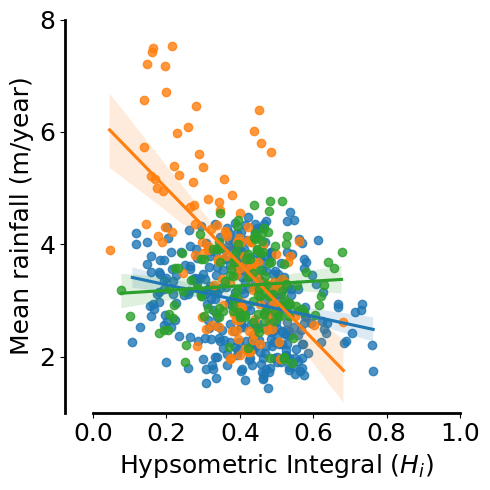

In [100]:
f,ax=plt.subplots(1,1,figsize=(5,5))
import seaborn as sns
import statsmodels.api as sm
sns.regplot(x=cat_cauca["hypso_inte"], y=cat_cauca["rainfall_cat"]/1000, ax=ax)
results = sm.OLS(cat_cauca["rainfall_cat"]/1000,sm.add_constant(cat_cauca["hypso_inte"])).fit()
print(results.summary())
sns.regplot(x=cat_atrato["hypso_inte"], y=cat_atrato["rainfall_cat"]/1000, ax=ax)
results = sm.OLS(cat_atrato["rainfall_cat"]/1000,sm.add_constant(cat_atrato["hypso_inte"])).fit()
print(results.summary())
sns.regplot(x=cat_magda["hypso_inte"], y=cat_magda["rainfall_cat"]/1000, ax=ax)
results = sm.OLS(cat_magda["rainfall_cat"]/1000,sm.add_constant(cat_magda["hypso_inte"])).fit()
print(results.summary())
ax.set_xlabel('Hypsometric Integral ($H_i$)',size=18)
ax.set_ylabel('Mean rainfall (m/year)',size=18)
ax.set_yticks(np.arange(0,8.1,2))
ax.set_xticks(np.arange(0,1.001,0.2))
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.set_xlim(0,1)
ax.set_ylim(1,8)
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(2)
sbn.despine(ax=ax,offset={'left': 20})


plt.legend(loc="upper right",frameon=False,prop={'size': 12})
f.tight_layout() 
#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/hypso_rainfall_basin.png", dpi=500)

#### Landslides

In [77]:
cat_cauca["lands_rec"].sum()/(cat_cauca["lands_rec"].sum()+cat_magda["lands_rec"].sum()+cat_atrato["lands_rec"].sum())

0.6110754561290914

In [79]:
cat_cauca["lands_rel"].sum()/(cat_cauca["lands_rel"].sum()+cat_magda["lands_rel"].sum()+cat_atrato["lands_rel"].sum())

0.7452229299363057

In [78]:
cat_atrato["lands_rec"].sum()/(cat_cauca["lands_rec"].sum()+cat_magda["lands_rec"].sum()+cat_atrato["lands_rec"].sum())

0.21811680572109654

In [70]:
cat_atrato["lands_rel"].sum()/(cat_cauca["lands_rel"].sum()+cat_magda["lands_rel"].sum()+cat_atrato["lands_rel"].sum())

0.1910828025477707

In [94]:
1081/13777

0.07846410684474124

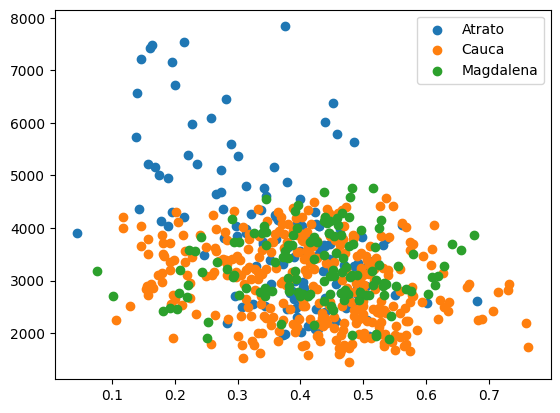

In [71]:
f,ax=plt.subplots()
ax.scatter(cat_atrato['hypso_inte'],cat_atrato['rainfall_cat'],label='Atrato')
ax.scatter(cat_cauca['hypso_inte'],cat_cauca['rainfall_cat'],label='Cauca')
ax.scatter(cat_magda['hypso_inte'],cat_magda['rainfall_cat'],label='Magdalena')
plt.legend();

In [72]:
cat_cauca=cat_10[(cat_10["cuenca"]=="Cauca")&(cat_10["landslides"]>0)]
cat_magda=cat_10[(cat_10["cuenca"]=="Magdalena")&(cat_10["landslides"]>0)]
cat_atrato=cat_10[(cat_10["cuenca"]=="Atrato")&(cat_10["landslides"]>0)]

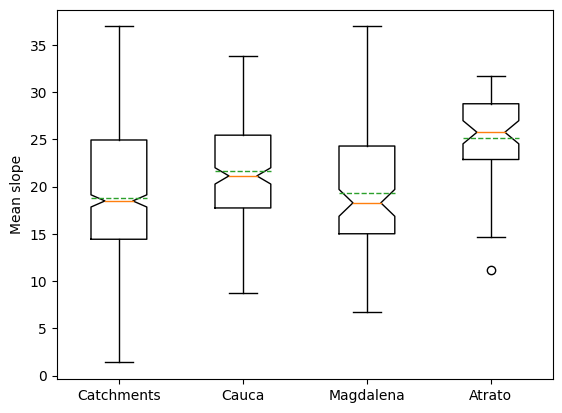

In [73]:
f,ax=plt.subplots()
#ax.boxplot()
ax.boxplot([cat_10["slope_mean"],cat_cauca["slope_mean"],cat_magda["slope_mean"],cat_atrato["slope_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean slope')
plt.xticks([1,2,3,4],['Catchments','Cauca','Magdalena','Atrato']);

In [ ]:
f,ax=plt.subplots()
ax.boxplot([cat_10["rel_mean"],cat_cauca["rel_mean"],cat_magda["rel_mean"],cat_atrato["rel_mean"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Mean relief')
plt.xticks([1,2,3,4],['Catchments','Cauca','Magdalena','Atrato']);

In [ ]:
plt.boxplot(cat_10["Área"]);

In [ ]:
area_mayor100=cat[cat_10["Área"]>100]

In [ ]:
area_mayor100.info()

In [115]:
area_menor100=cat[cat_10["Área"]<100]

In [118]:
area_menor100["Área"].median()

35.98463556495

In [ ]:
f,ax=plt.subplots()
ax.boxplot([area_mayor100["Área"],area_menor100["Área"]],showmeans=True,meanline=True,notch=True)
ax.set_ylabel('Area')
plt.xticks([1,2],['Catchments >100$km^2$','Catchments <100$km^2$']);

In [ ]:
area_mayor100[area_mayor100["Área"]>250].count()

In [ ]:
area_menor100["Área"].sum()/cat_10['Área'].sum()

In [ ]:
28/650